In [1]:

import os
os.environ["KERAS_BACKEND"] = "tensorflow" 

import keras
from keras import layers

import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

import matplotlib.pyplot as plt

[]


In [2]:
train_dataset = tf.data.Dataset.load('/Users/matteo/GitHub/RNN/datasets/train') 
val_dataset = tf.data.Dataset.load('/Users/matteo/GitHub/RNN/datasets/val') 
test_dataset = tf.data.Dataset.load('/Users/matteo/GitHub/RNN/datasets/test')

In [3]:
PAD = 999.0

def masked_mse(y_true, y_pred):
    mask = tf.cast(tf.reduce_all(y_true != PAD, axis=-1), tf.float32)   # (batch, T)
    sq = tf.reduce_sum(tf.square(y_true - y_pred), axis=-1)             # (batch, T)
    return tf.reduce_sum(sq * mask) / (tf.reduce_sum(mask) * 2)

In [4]:
for batch in train_dataset.take(1):
    features, y = batch
    x = features["enc_in"]

input_features_length = x.shape[-1]
print(input_features_length)

33


In [13]:
encoder_input = keras.Input(shape=(None, input_features_length), name="enc_in")
encoder_LSTM = layers.LSTM(128, return_state=True, name="encoder_lstm")
_, h, c = encoder_LSTM(layers.Masking(mask_value=PAD)(encoder_input))   # (h, c) = encoder end state

decoder_input = keras.Input(shape=(None, 2), name="dec_in")
decoder_LSTM = layers.LSTM(128, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_output, _, _ = decoder_LSTM(layers.Masking(mask_value=PAD)(decoder_input), initial_state=[h, c])

decoder_dense = layers.Dense(2, name="decoder_dense")
dense_output = decoder_dense(decoder_output)

model = keras.Model([encoder_input, decoder_input], dense_output)
model.compile(optimizer=keras.optimizers.Adam(1e-2), loss=masked_mse)
model.summary()






Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_in (InputLayer) │ (None, None, 33)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None, 33)  │          0 │ enc_in[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_in (InputLayer) │ (None, None, 2)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_4 (Masking) │ (None, None, 33)  │          0 │ enc_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, None)      │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_5 (Masking) │ (None, None, 2)   │          0 │ dec_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     82,944 │ masking_4[0][0],  │
│                     │ (None, 128),      │            │ any_4[0][0]       │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     67,072 │ masking_5[0][0],  │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 2)   │        258 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,274 (587.01 KB)

 Trainable params: 150,274 (587.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks =[
    keras.callbacks.ModelCheckpoint(
        filepath="build_baseline.keras",
        save_best_only=True,
        monitor="val_loss"
    ), 
    keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,       
    restore_best_weights=True
)
]


history = model.fit(train_dataset, validation_data=val_dataset, epochs=50, verbose=2, callbacks=callbacks)


Epoch 1/50
64/64 - 22s - 345ms/step - loss: 0.0737 - val_loss: 0.0026
Epoch 2/50
64/64 - 21s - 331ms/step - loss: 0.0014 - val_loss: 7.7775e-04
Epoch 3/50
64/64 - 22s - 347ms/step - loss: 5.8693e-04 - val_loss: 4.4486e-04
Epoch 4/50
64/64 - 22s - 341ms/step - loss: 3.8051e-04 - val_loss: 3.3154e-04
Epoch 5/50
64/64 - 21s - 335ms/step - loss: 2.8379e-04 - val_loss: 2.5482e-04
Epoch 6/50
64/64 - 21s - 327ms/step - loss: 2.2778e-04 - val_loss: 2.0932e-04
Epoch 7/50
64/64 - 21s - 328ms/step - loss: 2.0276e-04 - val_loss: 1.8140e-04
Epoch 8/50
64/64 - 21s - 331ms/step - loss: 1.7318e-04 - val_loss: 1.4024e-04
Epoch 9/50
64/64 - 22s - 339ms/step - loss: 1.5766e-04 - val_loss: 1.4310e-04
Epoch 10/50
64/64 - 22s - 342ms/step - loss: 1.2201e-04 - val_loss: 1.4335e-04
Epoch 11/50


KeyboardInterrupt: 

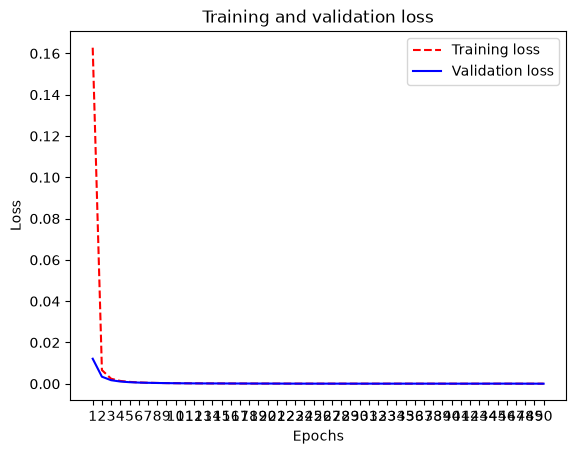

In [8]:

loss_values = history.history["loss"]
val_loss_values = history.history["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

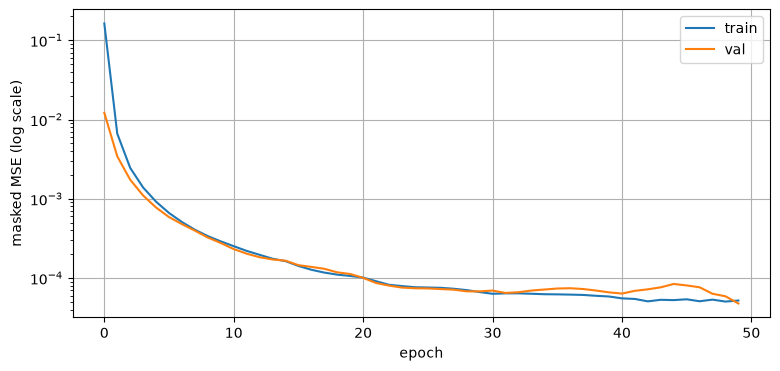

In [9]:
# --- A. Loss curves on a log scale (is the plateau real?)
plt.figure(figsize=(9, 4))
plt.semilogy(history.history["loss"], label="train")
plt.semilogy(history.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("masked MSE (log scale)")
plt.legend()
plt.grid(True)
plt.show()
# Everything after epoch ~8 looks flat on a linear axis;
# on a log axis you can see the model still improving slowly.

output length: train mean 12.2 vs val mean 12.2
persistence MSE: train 0.00203 vs val 0.00207
train per-batch persistence, first 8: [0.00199 0.00196 0.00221 0.00213 0.00172 0.00191 0.00188 0.00216]


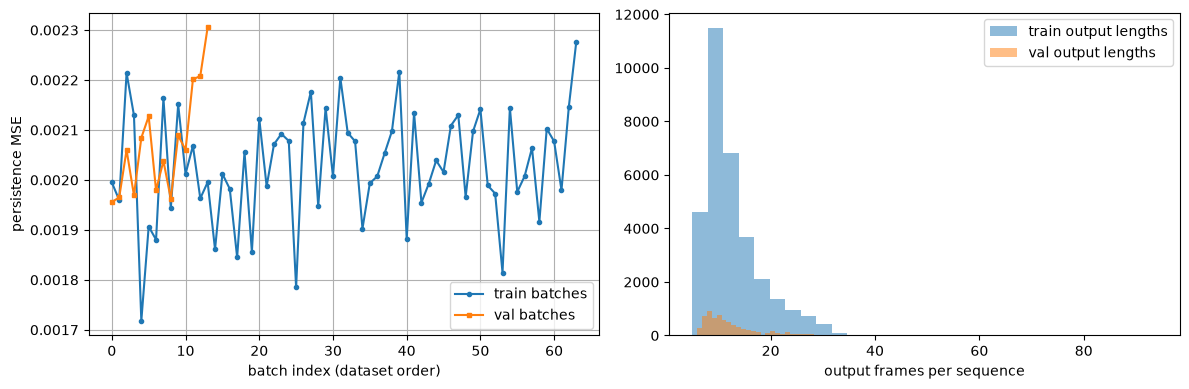

In [10]:
# --- B. Why is val_loss 13x LOWER than train_loss at epoch 1? Data-composition check.
import numpy as np

def per_batch_output_lengths(ds):
    lengths = []
    for features, y in ds:
        y = tf.convert_to_tensor(y)
        mask = tf.reduce_all(y != PAD, axis=-1)
        lengths.append(tf.reduce_sum(tf.cast(mask, tf.float32), axis=-1).numpy())
    return np.concatenate(lengths)

def per_batch_persistence_mse(ds):
    """Model-free difficulty proxy: MSE of 'next position = current position'."""
    values = []
    for features, y in ds:
        y = tf.convert_to_tensor(y)
        mask = tf.cast(tf.reduce_all(y != PAD, axis=-1)[:, 1:], tf.float32)
        sq = tf.reduce_sum(tf.square(y[:, 1:] - y[:, :-1]), axis=-1)
        total = tf.reduce_sum(sq * mask)
        n = tf.reduce_sum(mask)
        values.append(float(total / n))
    return np.array(values)

tr_len = per_batch_output_lengths(train_dataset)
va_len = per_batch_output_lengths(val_dataset)
tr_dif = per_batch_persistence_mse(train_dataset)
va_dif = per_batch_persistence_mse(val_dataset)

print(f"output length: train mean {tr_len.mean():.1f} vs val mean {va_len.mean():.1f}")
print(f"persistence MSE: train {tr_dif.mean():.5f} vs val {va_dif.mean():.5f}")
print(f"train per-batch persistence, first 8: {np.round(tr_dif[:8], 5)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(np.arange(len(tr_dif)), tr_dif, "o-", ms=3, label="train batches")
ax1.plot(np.arange(len(va_dif)), va_dif, "s-", ms=3, label="val batches")
ax1.set_xlabel("batch index (dataset order)")
ax1.set_ylabel("persistence MSE")
ax1.legend()
ax1.grid(True)
ax2.hist(tr_len, bins=30, alpha=0.5, label="train output lengths")
ax2.hist(va_len, bins=30, alpha=0.5, label="val output lengths")
ax2.set_xlabel("output frames per sequence")
ax2.legend()
plt.tight_layout()
plt.show()

In [11]:
# --- C. Autoregressive evaluation: does the RNN beat CatBoost (RMSE 1.97 yards)?
import numpy as np
import joblib
from pathlib import Path

# 1) Split the trained model into encoder + one-step decoder (same layer instances -> same weights)
encoder_model = keras.Model(encoder_input, [h, c])

dec_in_step = keras.Input(shape=(1, 2), name="dec_in_step")
dec_h_in = keras.Input(shape=(16,), name="dec_h_in")
dec_c_in = keras.Input(shape=(16,), name="dec_c_in")
dec_out_step, dec_h_out, dec_c_out = decoder_LSTM(dec_in_step, initial_state=[dec_h_in, dec_c_in])
dec_pred_step = decoder_dense(dec_out_step)
decoder_step = keras.Model([dec_in_step, dec_h_in, dec_c_in], [dec_pred_step, dec_h_out, dec_c_out])

def predict_autoregressive(x, n_steps):
    h0, c0 = encoder_model(x[None])               # encode the whole input once
    h0, c0 = np.asarray(h0), np.asarray(c0)
    step = np.zeros((1, 1, 2), dtype="float32")  # START token
    preds = []
    for _ in range(n_steps):
        p, h0, c0 = decoder_step([step, h0, c0])
        p, h0, c0 = np.asarray(p), np.asarray(h0), np.asarray(c0)
        preds.append(p[0, 0])
        step = p                                   # own output becomes next input
    return np.stack(preds)                         # (n_steps, 2)

def real_len(y):
    return int(np.sum(np.any(y != PAD, axis=-1)))

# 2) Roll out on a sample of val sequences (standardized units)
n_sample = 500
sse_x = sse_y = 0.0
n_x = n_y = 0
play_rmses = []
for features, y in val_dataset.unbatch().take(n_sample):
    x = features["enc_in"].numpy()
    y = np.asarray(y)
    T = real_len(y)
    if T < 1:
        continue
    pred = predict_autoregressive(x, T)
    err = pred - y[:T]
    sse_x += np.sum(err[:, 0] ** 2)
    sse_y += np.sum(err[:, 1] ** 2)
    n_x += T
    n_y += T
    play_rmses.append(np.sqrt(np.mean(err ** 2)))

rmse_x = np.sqrt(sse_x / n_x)
rmse_y = np.sqrt(sse_y / n_y)
rmse_norm = np.sqrt((rmse_x ** 2 + rmse_y ** 2) / 2)
print(f"standardized RMSE: x={rmse_x:.4f}  y={rmse_y:.4f}  pooled={rmse_norm:.4f}")
print(f"per-play RMSE: median {np.median(play_rmses):.4f}, mean {np.mean(play_rmses):.4f}")

# 3) Back to yards with the scaler that standardized x and y
scaler_path = Path("/Users/matteo/GitHub/RNN/datasets/scaler_coords.joblib")
if scaler_path.exists():
    scaler_coords = joblib.load(scaler_path)
    std = scaler_coords.scale_
    rmse_x_yards = rmse_x * std[0]
    rmse_y_yards = rmse_y * std[1]
    rmse_yards = np.sqrt((rmse_x_yards ** 2 + rmse_y_yards ** 2) / 2)
    print(f"RMSE in yards: x={rmse_x_yards:.3f}  y={rmse_y_yards:.3f}  pooled={rmse_yards:.3f}")
    print(f"CatBoost baseline RMSE: 1.97  ->  RNN {'wins' if rmse_yards < 1.97 else 'loses'}")
else:
    print("scaler_coords.joblib not found - re-run data_manipulation.py to save it")

standardized RMSE: x=0.0886  y=0.2238  pooled=0.1702
per-play RMSE: median 0.0676, mean 0.0912
RMSE in yards: x=2.083  y=2.273  pooled=2.180
CatBoost baseline RMSE: 1.97  ->  RNN loses
